In [1]:
import blackjack
import strategies 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def create_sim():
    return blackjack.Simulation(performance_mode=True, finite_deck=False, 
                           num_of_decks=6, penetration=0.7 , 
                           bets_active=True, bankroll=1000000, 
                           dealer_hit_17=True, blackjack_payout=1.5)

def monte_carlo(strategy, mc_runs:int=100, bj_rounds:int=10000, plot:bool=True, plot_points:int=500):
    step = max(1, bj_rounds // plot_points)
    histories = []
    evs = []
    
    for i in range(mc_runs):
        sim = create_sim()
        history = []

        for j in range(bj_rounds):
            sim.run(strategy)
            if plot and j % step == 0:
                history.append(sim.get_bankroll())
            
        evs.append(sim.get_player_ev())
        if plot: 
            histories.append(history)
            
    print('Finished')
    print(f'EV: {sum(evs)/len(evs)}')

    for h in histories:
        plt.plot(h, alpha=0.5, linewidth=0.5)

    plt.plot(np.mean(histories, axis=0), linewidth=2)

Finished
EV: -2.875


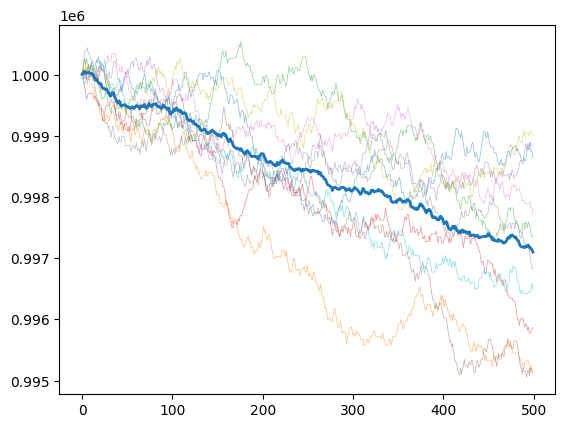

In [5]:
#choose the specifications for the simulation and the strategy to simulate with:
strategy = strategies.test

monte_carlo(strategy, mc_runs=10, bj_rounds=1000, plot_points=500)